In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("earthquakes.csv", usecols=['alert', 'code', 'detail', 'dmin', 'felt', 'mag', 'magType', 'place', 'rms', 'sig', 'sources', 'status', 'time', 'title', 'tsunami'])

In [6]:
df.shape

(9332, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9332 entries, 0 to 9331
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alert    59 non-null     object 
 1   code     9332 non-null   object 
 2   detail   9332 non-null   object 
 3   dmin     6139 non-null   float64
 4   felt     329 non-null    float64
 5   mag      9331 non-null   float64
 6   magType  9331 non-null   object 
 7   place    9332 non-null   object 
 8   rms      9332 non-null   float64
 9   sig      9332 non-null   int64  
 10  sources  9332 non-null   object 
 11  status   9332 non-null   object 
 12  time     9332 non-null   int64  
 13  title    9332 non-null   object 
 14  tsunami  9332 non-null   int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 1.1+ MB


### Specific column selection

In [5]:
# as attribute notation
df.mag

0       1.35
1       1.29
2       3.42
3       0.44
4       2.16
        ... 
9327    0.62
9328    1.00
9329    2.40
9330    1.10
9331    0.66
Name: mag, Length: 9332, dtype: float64

In [6]:
# as dictionary key notation
df["mag"]

0       1.35
1       1.29
2       3.42
3       0.44
4       2.16
        ... 
9327    0.62
9328    1.00
9329    2.40
9330    1.10
9331    0.66
Name: mag, Length: 9332, dtype: float64

In [7]:
# as list notation
df[["mag"]]

,mag
0,1.35
1,1.29
2,3.42
3,0.44
4,2.16
...,...
9327,0.62
9328,1.00
9329,2.40
9330,1.10


### Selecting multiple columns

In [8]:
df[["time", "title"]]

,time,title
0,1539475168010,"M 1.4 - 9km NE of Aguanga, CA"
1,1539475129610,"M 1.3 - 9km NE of Aguanga, CA"
2,1539475062610,"M 3.4 - 8km NE of Aguanga, CA"
3,1539474978070,"M 0.4 - 9km NE of Aguanga, CA"
4,1539474716050,"M 2.2 - 10km NW of Avenal, CA"
...,...,...
9327,1537230228060,"M 0.6 - 9km ENE of Mammoth Lakes, CA"
9328,1537230135130,"M 1.0 - 3km W of Julian, CA"
9329,1537229908180,"M 2.4 - 35km NNE of Hatillo, Puerto Rico"
9330,1537229545350,"M 1.1 - 9km NE of Aguanga, CA"


In [9]:
# selecting with list comprehension
df[["code"] + [col for col in df.columns if col.startswith('t')]]

,code,time,title,tsunami
0,37389218,1539475168010,"M 1.4 - 9km NE of Aguanga, CA",0
1,37389202,1539475129610,"M 1.3 - 9km NE of Aguanga, CA",0
2,37389194,1539475062610,"M 3.4 - 8km NE of Aguanga, CA",0
3,37389186,1539474978070,"M 0.4 - 9km NE of Aguanga, CA",0
4,73096941,1539474716050,"M 2.2 - 10km NW of Avenal, CA",0
...,...,...,...,...
9327,73086771,1537230228060,"M 0.6 - 9km ENE of Mammoth Lakes, CA",0
9328,38063967,1537230135130,"M 1.0 - 3km W of Julian, CA",0
9329,2018261000,1537229908180,"M 2.4 - 35km NNE of Hatillo, Puerto Rico",0
9330,38063959,1537229545350,"M 1.1 - 9km NE of Aguanga, CA",0


### Slicing

In [10]:
# selecting all columns
df[3:5]

,alert,code,detail,dmin,felt,mag,magType,place,rms,sig,sources,status,time,title,tsunami
3,NaN,37389186,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.02618,NaN,0.44,ml,"9km NE of Aguanga, CA",0.17,3,",ci,",automatic,1539474978070,"M 0.4 - 9km NE of Aguanga, CA",0
4,NaN,73096941,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.07799,NaN,2.16,md,"10km NW of Avenal, CA",0.05,72,",nc,",automatic,1539474716050,"M 2.2 - 10km NW of Avenal, CA",0


In [11]:
# selecting multiple columns
df[["code", "title", "status"]][3:5]

,code,title,status
3,37389186,"M 0.4 - 9km NE of Aguanga, CA",automatic
4,73096941,"M 2.2 - 10km NW of Avenal, CA",automatic


In [12]:
# order doesn't matter in above
df[3:5][["code", "title", "status"]]

,code,title,status
3,37389186,"M 0.4 - 9km NE of Aguanga, CA",automatic
4,73096941,"M 2.2 - 10km NW of Avenal, CA",automatic


In [13]:
# check two dataframes are equel
df[["code", "title", "status"]][3:5].equals(df[3:5][["code", "title", "status"]])

True

In [14]:
# slicing with step
df[5:15:2]

,alert,code,detail,dmin,felt,mag,magType,place,rms,sig,sources,status,time,title,tsunami
5,NaN,2018286011,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.43730,NaN,2.61,md,"55km ESE of Punta Cana, Dominican Republic",0.41,105,",pr,",reviewed,1539473686440,"M 2.6 - 55km ESE of Punta Cana, Dominican Repu...",0
7,NaN,73096936,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.01622,NaN,1.13,md,"10km NW of Parkfield, CA",0.05,20,",nc,",automatic,1539473060280,"M 1.1 - 10km NW of Parkfield, CA",0
9,NaN,1000hbtn,https://earthquake.usgs.gov/fdsnws/event/1/que...,3.19100,NaN,4.70,mb,"219km SSE of Saparua, Indonesia",0.78,340,",us,",reviewed,1539472814760,"M 4.7 - 219km SSE of Saparua, Indonesia",0
11,NaN,2018286010,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.94770,NaN,2.77,md,"53km SE of Punta Cana, Dominican Republic",0.53,118,",pr,",reviewed,1539471621260,"M 2.8 - 53km SE of Punta Cana, Dominican Republic",0
13,NaN,1000hbti,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.19300,NaN,4.50,mb,"120km SSW of Banda Aceh, Indonesia",0.69,312,",us,",reviewed,1539470898340,"M 4.5 - 120km SSW of Banda Aceh, Indonesia",0


In [15]:
# slicing for single column
df[3:5]["code"]

3    37389186
4    73096941
Name: code, dtype: object

### Indexing

In [16]:
# we can use indexing with loc and iloc, in loc end value is inclusive and in iloc end value is exclusive.
df.iloc[10:15, 8:10].equals(df.loc[10:14, "mag":"magType"])

False

In [17]:
# selecting first row with iloc
df.iloc[1]

alert                                                    NaN
code                                                37389202
detail     https://earthquake.usgs.gov/fdsnws/event/1/que...
dmin                                                 0.02003
felt                                                     NaN
mag                                                     1.29
magType                                                   ml
place                                  9km NE of Aguanga, CA
rms                                                     0.29
sig                                                       26
sources                                                 ,ci,
status                                             automatic
time                                           1539475129610
title                          M 1.3 - 9km NE of Aguanga, CA
tsunami                                                    0
Name: 1, dtype: object

In [18]:
# selecting first row with loc
df.loc[1]

alert                                                    NaN
code                                                37389202
detail     https://earthquake.usgs.gov/fdsnws/event/1/que...
dmin                                                 0.02003
felt                                                     NaN
mag                                                     1.29
magType                                                   ml
place                                  9km NE of Aguanga, CA
rms                                                     0.29
sig                                                       26
sources                                                 ,ci,
status                                             automatic
time                                           1539475129610
title                          M 1.3 - 9km NE of Aguanga, CA
tsunami                                                    0
Name: 1, dtype: object

### Scalar values

In [19]:
# selecting value from specific row and column with at
df.at[10, 'mag']

0.5

In [20]:
# selecting value from specific row and column with iat
df.iat[10, 8]

0.25

### filtering

In [21]:
# check from entire df with following condition, will give true or false
df.mag > 1

0        True
1        True
2        True
3       False
4        True
        ...  
9327    False
9328    False
9329     True
9330     True
9331    False
Name: mag, Length: 9332, dtype: bool

In [22]:
# filtering based on condition
df[df.mag > 7]

,alert,code,detail,dmin,felt,mag,magType,place,rms,sig,sources,status,time,title,tsunami
5263,red,1000h3p4,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.589,18.0,7.5,mww,"78km N of Palu, Indonesia",1.27,2015,",us,us,",reviewed,1538128963480,"M 7.5 - 78km N of Palu, Indonesia",1


In [24]:
# filter specific columns based on condition
df.loc[df.mag > 7, ["detail", "dmin", "felt"]]

,detail,dmin,felt
5263,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.589,18.0


In [25]:
df.loc[(df.tsunami == 1) & (df.alert == 'red'), ["detail", "dmin", "felt"]]

,detail,dmin,felt
5263,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.589,18.0


In [26]:
df.loc[(df.place.str.contains('Alaska')) & (df.alert.notnull()), ['alert', 'place']]

,alert,place
1015,green,"61km SSW of Chignik Lake, Alaska"
1273,green,"71km SW of Kaktovik, Alaska"
1795,green,"60km WNW of Valdez, Alaska"
2752,green,"67km SSW of Kaktovik, Alaska"
3260,green,"44km N of North Nenana, Alaska"
4101,green,"131km NNW of Arctic Village, Alaska"
6897,green,"80km SSW of Kaktovik, Alaska"
8524,green,"69km SSW of Kaktovik, Alaska"
9133,green,"64km SSW of Kaktovik, Alaska"


In [27]:
df.loc[df.mag.between(6.7, 7.0), ['alert', 'place']]

,alert,place
118,green,"262km NW of Ozernovskiy, Russia"
837,green,"117km E of Kimbe, Papua New Guinea"
4363,green,"263km NNE of Ndoi Island, Fiji"


In [28]:
df.loc[df.alert.isin(['red', 'orange']), ['alert', 'place']]

,alert,place
5263,red,"78km N of Palu, Indonesia"


In [29]:
df.loc[[df.mag.idxmin(), df.mag.idxmax()], ['alert', 'place']]

,alert,place
2409,NaN,"41km ENE of Adak, Alaska"
5263,red,"78km N of Palu, Indonesia"


In [30]:
df.filter(items=['alert', 'place']).head()

,alert,place
0,NaN,"9km NE of Aguanga, CA"
1,NaN,"9km NE of Aguanga, CA"
2,NaN,"8km NE of Aguanga, CA"
3,NaN,"9km NE of Aguanga, CA"
4,NaN,"10km NW of Avenal, CA"


In [31]:
df.filter(like='mag').head()

,mag,magType
0,1.35,ml
1,1.29,ml
2,3.42,ml
3,0.44,ml
4,2.16,md


### new columns

In [32]:
# create new column in dataframe
df["new_column"] = 1

In [33]:
df.columns

Index(['alert', 'code', 'detail', 'dmin', 'felt', 'mag', 'magType', 'place',
       'rms', 'sig', 'sources', 'status', 'time', 'title', 'tsunami',
       'new_column'],
      dtype='object')

In [34]:
# to create or update multiple columns in df
df.assign(is_problem = df.mag > 5, new_column = df.code.str.contains('a'))

,alert,code,detail,dmin,felt,mag,magType,place,rms,sig,sources,status,time,title,tsunami,new_column,is_problem
0,NaN,37389218,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.008693,NaN,1.35,ml,"9km NE of Aguanga, CA",0.19,28,",ci,",automatic,1539475168010,"M 1.4 - 9km NE of Aguanga, CA",0,False,False
1,NaN,37389202,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.020030,NaN,1.29,ml,"9km NE of Aguanga, CA",0.29,26,",ci,",automatic,1539475129610,"M 1.3 - 9km NE of Aguanga, CA",0,False,False
2,NaN,37389194,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.021370,28.0,3.42,ml,"8km NE of Aguanga, CA",0.22,192,",ci,",automatic,1539475062610,"M 3.4 - 8km NE of Aguanga, CA",0,False,False
3,NaN,37389186,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.026180,NaN,0.44,ml,"9km NE of Aguanga, CA",0.17,3,",ci,",automatic,1539474978070,"M 0.4 - 9km NE of Aguanga, CA",0,False,False
4,NaN,73096941,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.077990,NaN,2.16,md,"10km NW of Avenal, CA",0.05,72,",nc,",automatic,1539474716050,"M 2.2 - 10km NW of Avenal, CA",0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9327,NaN,73086771,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.018060,NaN,0.62,md,"9km ENE of Mammoth Lakes, CA",0.03,6,",nc,",reviewed,1537230228060,"M 0.6 - 9km ENE of Mammoth Lakes, CA",0,False,False
9328,NaN,38063967,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.030410,NaN,1.00,ml,"3km W of Julian, CA",0.21,15,",ci,",reviewed,1537230135130,"M 1.0 - 3km W of Julian, CA",0,False,False
9329,NaN,2018261000,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.452600,NaN,2.40,md,"35km NNE of Hatillo, Puerto Rico",0.41,89,",pr,",reviewed,1537229908180,"M 2.4 - 35km NNE of Hatillo, Puerto Rico",0,False,False
9330,NaN,38063959,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.018650,NaN,1.10,ml,"9km NE of Aguanga, CA",0.10,19,",ci,",reviewed,1537229545350,"M 1.1 - 9km NE of Aguanga, CA",0,False,False


### df concat

In [35]:
tsunami_df = df[df.tsunami == 1]

In [36]:
no_tsunami_df = df[df.tsunami == 0]

In [37]:
tsunami_df.shape, no_tsunami_df.shape

((61, 16), (9271, 16))

In [38]:
new_df = pd.concat([tsunami_df, no_tsunami_df])

In [39]:
new_df.shape

(9332, 16)

### delete columns

In [40]:
# Delete columns
del df['code']

In [41]:
df.columns

Index(['alert', 'detail', 'dmin', 'felt', 'mag', 'magType', 'place', 'rms',
       'sig', 'sources', 'status', 'time', 'title', 'tsunami', 'new_column'],
      dtype='object')

In [42]:
df.pop('sources')

0       ,ci,
1       ,ci,
2       ,ci,
3       ,ci,
4       ,nc,
        ... 
9327    ,nc,
9328    ,ci,
9329    ,pr,
9330    ,ci,
9331    ,ci,
Name: sources, Length: 9332, dtype: object

In [43]:
df.columns

Index(['alert', 'detail', 'dmin', 'felt', 'mag', 'magType', 'place', 'rms',
       'sig', 'status', 'time', 'title', 'tsunami', 'new_column'],
      dtype='object')

In [44]:
df.drop([1,4])

,alert,detail,dmin,felt,mag,magType,place,rms,sig,status,time,title,tsunami,new_column
0,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.008693,NaN,1.35,ml,"9km NE of Aguanga, CA",0.19,28,automatic,1539475168010,"M 1.4 - 9km NE of Aguanga, CA",0,1
2,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.021370,28.0,3.42,ml,"8km NE of Aguanga, CA",0.22,192,automatic,1539475062610,"M 3.4 - 8km NE of Aguanga, CA",0,1
3,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.026180,NaN,0.44,ml,"9km NE of Aguanga, CA",0.17,3,automatic,1539474978070,"M 0.4 - 9km NE of Aguanga, CA",0,1
5,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.437300,NaN,2.61,md,"55km ESE of Punta Cana, Dominican Republic",0.41,105,reviewed,1539473686440,"M 2.6 - 55km ESE of Punta Cana, Dominican Repu...",0,1
6,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,1.70,ml,"105km W of Talkeetna, Alaska",0.54,44,automatic,1539473176017,"M 1.7 - 105km W of Talkeetna, Alaska",0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9327,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.018060,NaN,0.62,md,"9km ENE of Mammoth Lakes, CA",0.03,6,reviewed,1537230228060,"M 0.6 - 9km ENE of Mammoth Lakes, CA",0,1
9328,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.030410,NaN,1.00,ml,"3km W of Julian, CA",0.21,15,reviewed,1537230135130,"M 1.0 - 3km W of Julian, CA",0,1
9329,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.452600,NaN,2.40,md,"35km NNE of Hatillo, Puerto Rico",0.41,89,reviewed,1537229908180,"M 2.4 - 35km NNE of Hatillo, Puerto Rico",0,1
9330,NaN,https://earthquake.usgs.gov/fdsnws/event/1/que...,0.018650,NaN,1.10,ml,"9km NE of Aguanga, CA",0.10,19,reviewed,1537229545350,"M 1.1 - 9km NE of Aguanga, CA",0,1


In [45]:
df.empty

False

In [46]:
# identify data types of each column
df.dtypes

alert          object
detail         object
dmin          float64
felt          float64
mag           float64
magType        object
place          object
rms           float64
sig             int64
status         object
time            int64
title          object
tsunami         int64
new_column      int64
dtype: object

In [47]:
# check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9332 entries, 0 to 9331
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   alert       59 non-null     object 
 1   detail      9332 non-null   object 
 2   dmin        6139 non-null   float64
 3   felt        329 non-null    float64
 4   mag         9331 non-null   float64
 5   magType     9331 non-null   object 
 6   place       9332 non-null   object 
 7   rms         9332 non-null   float64
 8   sig         9332 non-null   int64  
 9   status      9332 non-null   object 
 10  time        9332 non-null   int64  
 11  title       9332 non-null   object 
 12  tsunami     9332 non-null   int64  
 13  new_column  9332 non-null   int64  
dtypes: float64(4), int64(4), object(6)
memory usage: 1020.8+ KB


In [48]:
# describing interger value columns
df.describe()

,dmin,felt,mag,rms,sig,time,tsunami,new_column
count,6139.000000,329.000000,9331.000000,9332.000000,9332.000000,9.332000e+03,9332.000000,9332.0
mean,0.544925,12.310030,1.497345,0.362122,56.899914,1.538284e+12,0.006537,1.0
std,2.214305,48.954944,1.203347,0.317784,91.872163,6.080306e+08,0.080589,0.0
min,0.000648,0.000000,-1.260000,0.000000,0.000000,1.537229e+12,0.000000,1.0
25%,0.020425,1.000000,0.720000,0.119675,8.000000,1.537793e+12,0.000000,1.0
50%,0.059050,2.000000,1.300000,0.210000,26.000000,1.538245e+12,0.000000,1.0
75%,0.177250,5.000000,1.900000,0.590000,56.000000,1.538766e+12,0.000000,1.0
max,53.737000,580.000000,7.500000,1.910000,2015.000000,1.539475e+12,1.000000,1.0


In [49]:
# describing all columns
df.describe(include='all')

,alert,detail,dmin,felt,mag,magType,place,rms,sig,status,time,title,tsunami,new_column
count,59,9332,6139.000000,329.000000,9331.000000,9331,9332,9332.000000,9332.000000,9332,9.332000e+03,9332,9332.000000,9332.0
unique,2,9332,NaN,NaN,NaN,10,5433,NaN,NaN,2,NaN,7807,NaN,NaN
top,green,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,ml,"10km NE of Aguanga, CA",NaN,NaN,reviewed,NaN,"M 0.4 - 10km NE of Aguanga, CA",NaN,NaN
freq,58,1,NaN,NaN,NaN,6803,306,NaN,NaN,7797,NaN,55,NaN,NaN
mean,NaN,NaN,0.544925,12.310030,1.497345,NaN,NaN,0.362122,56.899914,NaN,1.538284e+12,NaN,0.006537,1.0
std,NaN,NaN,2.214305,48.954944,1.203347,NaN,NaN,0.317784,91.872163,NaN,6.080306e+08,NaN,0.080589,0.0
min,NaN,NaN,0.000648,0.000000,-1.260000,NaN,NaN,0.000000,0.000000,NaN,1.537229e+12,NaN,0.000000,1.0
25%,NaN,NaN,0.020425,1.000000,0.720000,NaN,NaN,0.119675,8.000000,NaN,1.537793e+12,NaN,0.000000,1.0
50%,NaN,NaN,0.059050,2.000000,1.300000,NaN,NaN,0.210000,26.000000,NaN,1.538245e+12,NaN,0.000000,1.0
75%,NaN,NaN,0.177250,5.000000,1.900000,NaN,NaN,0.590000,56.000000,NaN,1.538766e+12,NaN,0.000000,1.0


In [50]:
# describing specific columns
df[["dmin", "felt"]].describe()

,dmin,felt
count,6139.000000,329.000000
mean,0.544925,12.310030
std,2.214305,48.954944
min,0.000648,0.000000
25%,0.020425,1.000000
50%,0.059050,2.000000
75%,0.177250,5.000000
max,53.737000,580.000000


In [51]:
# one column describe
df.dmin.describe()

count    6139.000000
mean        0.544925
std         2.214305
min         0.000648
25%         0.020425
50%         0.059050
75%         0.177250
max        53.737000
Name: dmin, dtype: float64

In [52]:
df.status.unique()

array(['automatic', 'reviewed'], dtype=object)

In [53]:
df.status.value_counts()

status
reviewed     7797
automatic    1535
Name: count, dtype: int64

Text(0, 0.5, 'combined columns')

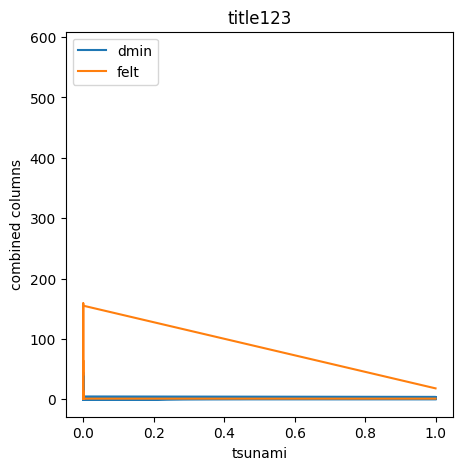

In [61]:
df.plot(kind='line', y=['dmin', 'felt'], x='tsunami', title="title123", figsize=(5, 5)).set_ylabel('combined columns')